## Load and preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
GCMS_CSV_PATH = './data/'+'GCMS化合物鉴定表'+'.csv'
gcms_data = pd.read_csv(GCMS_CSV_PATH) #GCMS 化合物鉴定表

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['M','S'], yticklabels=['M','S'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

首先分开标签（S，M）和数据，每列是一个feature，每行是一个sample

In [3]:
import torch
y = gcms_data.columns.tolist()[4:]
y_labels = []
X = np.array(gcms_data[y]).T
for i in y:
    if 'S' in i:
        y_labels.append(1)
    else:
        y_labels.append(0)
y_labels = torch.from_numpy(np.array(y_labels))

## K-mean method:

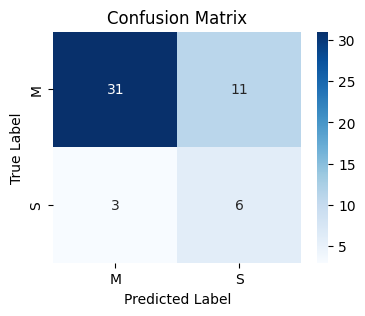

In [4]:
from sklearn.cluster import KMeans
k = 2 
kmeans = KMeans(n_clusters=k, n_init=30, random_state=42) # different random state cause different convergence
cluster_labels = kmeans.fit_predict(X)
cm(y_labels, cluster_labels)

## GaussianMixture method:

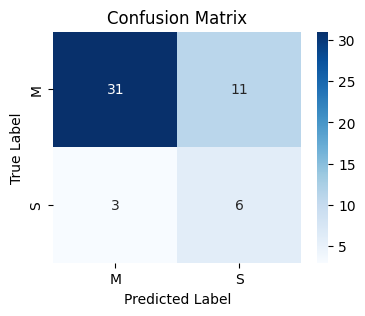

In [5]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=2, n_init=30, random_state=11)
cluster_labels = gmm.fit_predict(X)
inverted_data = [1 if x == 0 else 0 for x in cluster_labels]
cm(y_labels, inverted_data)

## Analysis

In [7]:
centers = kmeans.cluster_centers_
del_distance = abs(np.linalg.norm((X-centers[0]),axis=1)-np.linalg.norm((X-centers[1]),axis=1)) # 用l2norm的差值判断是否处于模糊地带
indices = np.argsort(del_distance)
print("Small differences"+str([y[i] for i in indices[:15]]))

Small differences['M26', 'M8', 'M36', 'M23', 'M22', 'M39', 'M25', 'M6', 'M29', 'M28', 'M37', 'M24', 'M30', 'S7', 'M11']


In [8]:
diff_indices = [i for i in range(len(y_labels)) if y_labels[i] != inverted_data[i]]
sorted_diff_indices=[]
for i in indices:
    if i in diff_indices:
        sorted_diff_indices.append(i)
print("Wrong Clusters:"+str([y[i]for i in sorted_diff_indices]))

Wrong Clusters:['M26', 'M36', 'M23', 'M22', 'M39', 'M25', 'M29', 'M28', 'M37', 'M24', 'M30', 'M35', 'M27', 'M40', 'M41', 'M34', 'M33', 'M32', 'M38', 'M31', 'M1']


In [9]:
distance = abs(centers[0]-centers[1])
indices = np.argsort(distance)[::-1] # 根据k-mean的聚集点找到相隔较远的feature
for i in indices[:6]:
    print(gcms_data.loc[i,'化合物名称']+'\n \t距离: '+str(distance[i]))

Propanoic acid, 2-hydroxy-, ethyl ester
 	距离: 51.40518783235294
1-Butanol, 3-methyl-
 	距离: 32.76945805647057
1-Propanol, 2-methyl-
 	距离: 16.363990448529417
Furfural
 	距离: 16.074356967058826
Butanoic acid, ethyl ester
 	距离: 9.273669780294114
1-Butanol
 	距离: 9.197807573294119
